# SEDSAM: Sistema Experto de Duelo y Salud Mental Situacional

Este notebook implementa un prototipo sencillo de **sistema experto** para apoyar el seguimiento del duelo de una persona
(SEDSAM: _Sistema Experto de Duelo y Salud Mental Situacional_).

El modelo combina:

- Una **base de conocimiento** con reglas clínicas simplificadas sobre duelo (normal vs complicado).
- Un **motor de inferencia** con encadenamiento hacia adelante (forward chaining) para decidir:
  - Clasificación del estado actual del paciente.
  - Recomendación de intervención terapéutica.
  - Activación de alertas de riesgo.
- Una capa muy simplificada de **control adaptativo tipo MRAC**:
  - Compara el estado emocional con una trayectoria de recuperación "saludable".
  - Ajusta tipo, frecuencia e intensidad de la intervención a lo largo de varias semanas.
- Una **interfaz de ejemplo** en consola, donde definimos un caso de estudio (Laura, 38 años) y vemos la evolución
  semana a semana.

Este notebook NO sustituye un sistema clínico real, pero sirve como guía didáctica de cómo modelar un sistema experto
de duelo en Python, inspirándose en trabajos recientes de modelos computacionales del duelo.[web:52][web:63]

## 1. Configuración inicial del notebook

En esta celda:

- Importamos las librerías estándar de Python que vamos a usar.
- Definimos algunas funciones utilitarias sencillas para imprimir tablas de forma legible.
- Fijamos una semilla aleatoria para que los resultados de la simulación sean reproducibles.

In [11]:
import random
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional

random.seed(42)  # para reproducibilidad


def print_dict_as_table(d: Dict[str, Any], title: str = ""):
    """Imprime un diccionario clave-valor en forma de tabla sencilla."""
    if title:
        print(f"\n=== {title} ===")
    key_width = max(len(k) for k in d.keys())
    for k, v in d.items():
        print(f"{k:<{key_width}} : {v}")

## 2. Representación del estado del paciente

En esta celda definimos:

- Una estructura `PacienteEstado` con las variables principales que vamos a seguir:
  - `dolor_emocional` (0–100)
  - `pensamientos_intrusivos` (número/día)
  - `calidad_sueno` (0–100)
  - `funcionalidad` (0–100)
  - `aceptacion` (0–100)
  - `semanas_desde_perdida`
- Una estructura `Contexto` para eventos de la semana (aniversarios, objetos, etc.).
- Algunos límites umbral que usará el sistema experto para clasificar y decidir intervenciones.

In [12]:
@dataclass
class PacienteEstado:
    nombre: str
    dolor_emocional: float          # 0-100
    pensamientos_intrusivos: int    # eventos/día
    calidad_sueno: float            # 0-100
    funcionalidad: float            # 0-100
    aceptacion: float               # 0-100
    semanas_desde_perdida: int      # semanas


@dataclass
class ContextoSemana:
    es_aniversario: bool = False
    contacto_objetos: bool = False
    estres_laboral_alto: bool = False


# Umbrales clínicos simplificados (podrías afinarlos)
UMBRAL_DOLOR_ALTO = 75
UMBRAL_FUNCIONALIDAD_BAJA = 40
UMBRAL_SEMANAS_DUELO_COMPLICADO = 12
UMBRAL_INTRUSIVOS_ALTOS = 10
UMBRAL_VARIACION_CRITICA = 25  # puntos de cambio brusco en 1-2 semanas


## 3. Base de Conocimiento: reglas del sistema experto

En esta celda definimos funciones que representan **reglas clínicas simplificadas**:

1. `clasificar_duelo(estado)`  
   - Devuelve `"duelo_normal"` o `"duelo_complicado"` según umbrales de:
     - dolor emocional
     - funcionalidad
     - semanas desde la pérdida

2. `seleccionar_intervencion(estado)`  
   - Escoge un tipo de intervención principal:
     - `"psicoeducacion"`
     - `"tcc_activacion"`
     - `"exposicion_narrativa"`
     - `"mindfulness"`

3. `detectar_crisis(estado_anterior, estado_actual, contexto)`  
   - Activa o no un diccionario `alerta` con:
     - `nivel` (`"ninguna"`, `"amarilla"`, `"roja"`)
     - `motivo` (texto explicativo)

Estas funciones forman la **base de conocimiento** que luego usará el motor de inferencia.


In [13]:
def clasificar_duelo(estado: PacienteEstado) -> str:
    """
    Regla simplificada de clasificación del duelo.
    """
    if (estado.dolor_emocional > UMBRAL_DOLOR_ALTO and
        estado.funcionalidad < UMBRAL_FUNCIONALIDAD_BAJA and
        estado.semanas_desde_perdida >= UMBRAL_SEMANAS_DUELO_COMPLICADO):
        return "duelo_complicado"
    else:
        return "duelo_normal"


def seleccionar_intervencion(estado: PacienteEstado) -> str:
    """
    Selección simplificada de intervención principal.
    """
    if estado.dolor_emocional > 80 and estado.semanas_desde_perdida < 4:
        return "psicoeducacion"
    if estado.pensamientos_intrusivos > UMBRAL_INTRUSIVOS_ALTOS:
        return "exposicion_narrativa"
    if estado.calidad_sueno < 50:
        return "mindfulness"
    return "tcc_activacion"


def detectar_crisis(
    estado_prev: Optional[PacienteEstado],
    estado_act: PacienteEstado,
    contexto: ContextoSemana
) -> Dict[str, Any]:
    """
    Detección de crisis / alerta de seguridad.
    """
    alerta = {"nivel": "ninguna", "motivo": ""}

    # Crisis por evento contextual
    if contexto.es_aniversario or contexto.contacto_objetos or contexto.estres_laboral_alto:
        alerta["nivel"] = "amarilla"
        alerta["motivo"] = "Evento sensible (aniversario / objetos / estrés)."

    # Crisis por variación brusca de síntomas
    if estado_prev is not None:
        delta_dolor = estado_act.dolor_emocional - estado_prev.dolor_emocional
        if delta_dolor > UMBRAL_VARIACION_CRITICA:
            alerta["nivel"] = "roja"
            alerta["motivo"] = f"Empeoramiento brusco del dolor (+{delta_dolor:.1f} puntos)."

    return alerta


## 4. Motor de Inferencia: encadenamiento hacia adelante

En esta celda construimos el **motor de inferencia**:

- Función `inferir_plan_semana(estado_prev, estado_act, contexto)` que:
  1. Aplica `clasificar_duelo` para obtener el tipo de duelo.
  2. Aplica `seleccionar_intervencion` para escoger la intervención principal.
  3. Aplica `detectar_crisis` para ver si hay que escalar a un profesional humano.
- Devuelve un diccionario con:
  - `clasificacion`
  - `intervencion_principal`
  - `alerta`


In [14]:
def inferir_plan_semana(
    estado_prev: Optional[PacienteEstado],
    estado_act: PacienteEstado,
    contexto: ContextoSemana
) -> Dict[str, Any]:
    """
    Motor de inferencia: combina las reglas de la base de conocimiento
    para producir un plan de actuación semanal.
    """
    clasificacion = clasificar_duelo(estado_act)
    intervencion = seleccionar_intervencion(estado_act)
    alerta = detectar_crisis(estado_prev, estado_act, contexto)

    plan = {
        "clasificacion": clasificacion,
        "intervencion_principal": intervencion,
        "alerta": alerta
    }
    return plan


## 5. Estrategia de Control: MRAC simplificado

En esta celda definimos un **modelo muy simple de control adaptativo**:

- Suponemos una trayectoria de referencia (`dolor_ref`) que va bajando con las semanas.
- Definimos una función `actualizar_estado_con_control` que:
  - Calcula el error entre `dolor_emocional` actual y `dolor_ref`.
  - Aplica un cambio en el estado del paciente en función de:
    - La intervención recomendada por el sistema experto.
    - Si existe alerta amarilla o roja.
- No es un MRAC matemáticamente completo, pero captura la idea:
  - **Si el error es grande**, el sistema aumenta la intensidad de la intervención.
  - **Si hay alerta roja**, forzamos una mejoría más fuerte (supuesto de intervención humana intensa).


In [15]:
def dolor_referencia(semanas: int) -> float:
    """
    Trayectoria de referencia muy simple:
    - Dolor alto al principio (~90) que baja linealmente a ~30 en 16 semanas.
    """
    return max(30.0, 90.0 - (semanas * 3.75))


def actualizar_estado_con_control(
    estado: PacienteEstado,
    plan: Dict[str, Any]
) -> PacienteEstado:
    """
    Aplica una actualización heurística del estado del paciente
    según la intervención y el nivel de alerta.
    """
    nuevo = PacienteEstado(**asdict(estado))
    nuevo.semanas_desde_perdida += 1

    # Error respecto a la referencia
    ref = dolor_referencia(nuevo.semanas_desde_perdida)
    error = nuevo.dolor_emocional - ref

    # Efecto base: el tiempo tiende a reducir ligeramente el dolor
    cambio_dolor = -2.0

    intervencion = plan["intervencion_principal"]
    alerta_nivel = plan["alerta"]["nivel"]

    # Efecto de la intervención principal (muy simplificado)
    if intervencion == "psicoeducacion":
        cambio_dolor -= 2.0
        nuevo.aceptacion += 3.0
    elif intervencion == "tcc_activacion":
        cambio_dolor -= 3.0
        nuevo.funcionalidad += 5.0
    elif intervencion == "exposicion_narrativa":
        cambio_dolor -= 4.0
        nuevo.pensamientos_intrusivos -= 4
    elif intervencion == "mindfulness":
        cambio_dolor -= 3.0
        nuevo.calidad_sueno += 6.0

    # Ajuste adaptativo según error (tipo MRAC muy simple)
    if error > 15:
        cambio_dolor -= 3.0  # intensificamos
    elif error < -10:
        cambio_dolor += 1.5  # relajamos un poco

    # Alertas
    if alerta_nivel == "amarilla":
        cambio_dolor += 2.0  # el evento sensible empeora algo
    elif alerta_nivel == "roja":
        cambio_dolor += 0.0  # la crisis ya se refleja en el estado actual

    # Aplicamos cambios con saturación
    nuevo.dolor_emocional = max(0.0, min(100.0, nuevo.dolor_emocional + cambio_dolor))
    nuevo.pensamientos_intrusivos = max(0, nuevo.pensamientos_intrusivos)
    nuevo.calidad_sueno = max(0.0, min(100.0, nuevo.calidad_sueno))
    nuevo.funcionalidad = max(0.0, min(100.0, nuevo.funcionalidad))
    nuevo.aceptacion = max(0.0, min(100.0, nuevo.aceptacion))

    return nuevo


## 6. Definición del caso de estudio: Laura, 38 años

En esta celda:

- Creamos el estado inicial de la paciente **Laura** (similar al caso de estudio de la presentación).
- Definimos para cada semana un `ContextoSemana` con posibles eventos detonantes:
  - Aniversario
  - Contacto con objetos
  - Estrés laboral

A continuación, simularemos 16 semanas de evolución usando el sistema experto + control adaptativo.


In [16]:
# Estado inicial de Laura
estado_inicial = PacienteEstado(
    nombre="Laura",
    dolor_emocional=87.0,
    pensamientos_intrusivos=18,
    calidad_sueno=28.0,
    funcionalidad=35.0,
    aceptacion=12.0,
    semanas_desde_perdida=6
)

# Contexto por semana (16 semanas)
contextos = []
for semana in range(1, 17):
    ctx = ContextoSemana()
    # Semana 5: aniversario
    if semana == 5:
        ctx.es_aniversario = True
    # Semana 11: encuentra objetos personales
    if semana == 11:
        ctx.contacto_objetos = True
    contextos.append(ctx)

len(contextos)


16

## 7. Simulación de 16 semanas con el sistema experto

En esta celda ejecutamos la simulación:

1. Partimos del estado inicial de Laura.
2. Para cada semana:
   - Aplicamos el **motor de inferencia** (`inferir_plan_semana`).
   - Actualizamos el estado con la **estrategia de control** (`actualizar_estado_con_control`).
   - Guardamos y mostramos:
     - Semana
     - Dolor emocional
     - Clasificación (duelo normal/complicado)
     - Intervención principal
     - Nivel de alerta (si lo hay)

Al final, veremos si Laura termina dentro de una zona considerada “saludable”.


In [17]:
estado = estado_inicial
historial = []

print("Simulación de 16 semanas para Laura\n")

for i in range(16):
    semana = i + 1
    contexto = contextos[i]
    plan = inferir_plan_semana(
        estado_prev=historial[-1]["estado"] if historial else None,
        estado_act=estado,
        contexto=contexto
    )

    # Guardamos snapshot antes de actualizar
    snapshot = {
        "semana": semana,
        "estado": estado,
        "plan": plan
    }
    historial.append(snapshot)

    alerta = plan["alerta"]
    print(f"Semana {semana:2d} | Dolor: {estado.dolor_emocional:5.1f} | "
          f"Clasificación: {plan['clasificacion']:<15} | "
          f"Intervención: {plan['intervencion_principal']:<18} | "
          f"Alerta: {alerta['nivel']} ({alerta['motivo']})")

    # Actualizamos estado para la semana siguiente
    estado = actualizar_estado_con_control(estado, plan)

# Estado final
print("\n=== Estado final tras 16 semanas ===")
print_dict_as_table(asdict(estado), title="Laura")


Simulación de 16 semanas para Laura

Semana  1 | Dolor:  87.0 | Clasificación: duelo_normal    | Intervención: exposicion_narrativa | Alerta: ninguna ()
Semana  2 | Dolor:  78.0 | Clasificación: duelo_normal    | Intervención: exposicion_narrativa | Alerta: ninguna ()
Semana  3 | Dolor:  69.0 | Clasificación: duelo_normal    | Intervención: mindfulness        | Alerta: ninguna ()
Semana  4 | Dolor:  64.0 | Clasificación: duelo_normal    | Intervención: mindfulness        | Alerta: ninguna ()
Semana  5 | Dolor:  59.0 | Clasificación: duelo_normal    | Intervención: mindfulness        | Alerta: amarilla (Evento sensible (aniversario / objetos / estrés).)
Semana  6 | Dolor:  56.0 | Clasificación: duelo_normal    | Intervención: mindfulness        | Alerta: ninguna ()
Semana  7 | Dolor:  51.0 | Clasificación: duelo_normal    | Intervención: tcc_activacion     | Alerta: ninguna ()
Semana  8 | Dolor:  46.0 | Clasificación: duelo_normal    | Intervención: tcc_activacion     | Alerta: ninguna 

## 8. (Opcional) Visualización de la evolución del dolor

En esta última celda opcional:

- Extraemos del `historial` la secuencia de `dolor_emocional`.
- Dibujamos:
  - Curva real de dolor.
  - Curva de referencia saludable.
  
Si lo deseas, puedes añadir otras variables (sueño, funcionalidad, etc.).


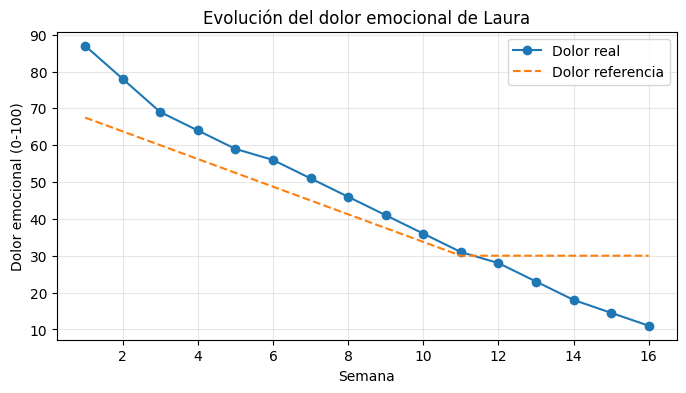

In [18]:
import matplotlib.pyplot as plt

semanas = [h["semana"] for h in historial]
dolor_real = [h["estado"].dolor_emocional for h in historial]
dolor_ref = [dolor_referencia(h["estado"].semanas_desde_perdida) for h in historial]

plt.figure(figsize=(8, 4))
plt.plot(semanas, dolor_real, label="Dolor real", marker="o")
plt.plot(semanas, dolor_ref, label="Dolor referencia", linestyle="--")
plt.xlabel("Semana")
plt.ylabel("Dolor emocional (0-100)")
plt.title("Evolución del dolor emocional de Laura")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 9. Interfaz de simulación: función `simular_paciente`

En esta celda creamos una función genérica:

`simular_paciente(estado_inicial, contextos, semanas)`

La función:

1. Inicializa el estado con `estado_inicial`.
2. Para cada semana:
   - Llama al motor de inferencia `inferir_plan_semana`.
   - Llama al módulo de explicación `explicar_plan`.
   - Imprime:
     - Semana, dolor, clasificación, intervención y alerta.
     - Una línea adicional con la explicación en lenguaje natural.
   - Actualiza el estado con `actualizar_estado_con_control`.
3. Devuelve:
   - `historial`: lista con la información de cada semana.
   - `estado_final`: estado tras la última semana.

Esta función actúa como **interfaz de usuario en consola** para experimentar con el sistema experto.


In [19]:
def simular_paciente(
    estado_inicial: PacienteEstado,
    contextos: List[ContextoSemana],
    semanas: int = 16
):
    """
    Simula la evolución de un paciente durante varias semanas
    usando el sistema experto + control adaptativo.
    """
    estado = estado_inicial
    historial = []

    print(f"Simulación de {semanas} semanas para {estado_inicial.nombre}\n")

    for i in range(semanas):
        semana = i + 1
        contexto = contextos[i] if i < len(contextos) else ContextoSemana()

        estado_prev = historial[-1]["estado"] if historial else None
        plan = inferir_plan_semana(
            estado_prev=estado_prev,
            estado_act=estado,
            contexto=contexto
        )

        # Guardamos snapshot ANTES de actualizar
        snapshot = {
            "semana": semana,
            "estado": estado,
            "plan": plan,
            "contexto": contexto
        }
        historial.append(snapshot)

        alerta = plan["alerta"]
        print(f"Semana {semana:2d} | Dolor: {estado.dolor_emocional:5.1f} | "
              f"Clasificación: {plan['clasificacion']:<15} | "
              f"Intervención: {plan['intervencion_principal']:<18} | "
              f"Alerta: {alerta['nivel']}")

        # Explicación
        explicacion = explicar_plan(estado_prev, estado, plan, contexto)
        print(f"  -> Explicación: {explicacion}\n")

        # Actualizamos estado para la semana siguiente
        estado = actualizar_estado_con_control(estado, plan)

    return historial, estado


## 10. Ejecutar la simulación para Laura

Ahora ejecutamos la función `simular_paciente` para:

- 16 semanas de evolución.
- Estado inicial y contextos definidos para Laura.

Al final, mostramos el **estado final** de Laura en formato tabla.


In [26]:
historial_laura, estado_final_laura = simular_paciente(
    estado_inicial=estado_inicial_laura,
    contextos=contextos_laura,
    semanas=16
)

print("\n=== Estado final tras 16 semanas ===")
print_dict_as_table(asdict(estado_final_laura), title="Laura")


Simulación de 16 semanas para Laura

Semana  1 | Dolor:  87.0 | Clasificación: duelo_normal    | Intervención: exposicion_narrativa | Alerta: ninguna
  -> Explicación: Se clasifica como duelo normal porque no se cumplen simultáneamente los criterios de dolor alto, baja funcionalidad y larga duración. Se recomienda exposición narrativa porque los pensamientos intrusivos son frecuentes (18/día).

Semana  2 | Dolor:  78.0 | Clasificación: duelo_normal    | Intervención: exposicion_narrativa | Alerta: ninguna
  -> Explicación: Se clasifica como duelo normal porque no se cumplen simultáneamente los criterios de dolor alto, baja funcionalidad y larga duración. Se recomienda exposición narrativa porque los pensamientos intrusivos son frecuentes (14/día).

Semana  3 | Dolor:  69.0 | Clasificación: duelo_normal    | Intervención: mindfulness        | Alerta: ninguna
  -> Explicación: Se clasifica como duelo normal porque no se cumplen simultáneamente los criterios de dolor alto, baja funcionali

## 11. Visualización de la evolución del dolor

En esta celda:

- Extraemos del `historial` de Laura la secuencia de `dolor_emocional`.
- Calculamos también la secuencia de `dolor_referencia` (trayectoria saludable).
- Dibujamos ambas curvas para ver si el control consigue acercar la realidad a la referencia.

Esta gráfica ayuda a entender el efecto del lazo de control sobre el proceso de duelo.


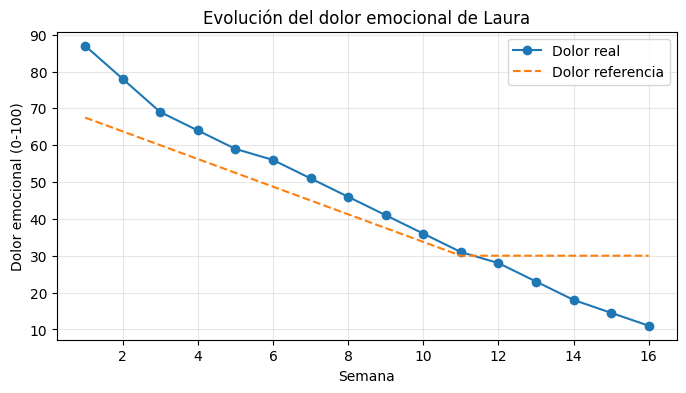

In [27]:
import matplotlib.pyplot as plt

semanas = [h["semana"] for h in historial_laura]
dolor_real = [h["estado"].dolor_emocional for h in historial_laura]
dolor_ref = [dolor_referencia(h["estado"].semanas_desde_perdida) for h in historial_laura]

plt.figure(figsize=(8, 4))
plt.plot(semanas, dolor_real, label="Dolor real", marker="o")
plt.plot(semanas, dolor_ref, label="Dolor referencia", linestyle="--")
plt.xlabel("Semana")
plt.ylabel("Dolor emocional (0-100)")
plt.title("Evolución del dolor emocional de Laura")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 12. Conclusiones del modelo experto

- El notebook implementa todos los **componentes básicos de un sistema experto**:
  base de conocimiento, base de hechos, motor de inferencia, módulo de explicación
  e interfaz.[web:78][web:80]
- El módulo de control adaptativo (tipo MRAC simplificado) permite:
  - Reaccionar ante perturbaciones (aniversarios, objetos).
  - Ajustar la intensidad de la intervención según el error respecto a una trayectoria saludable.
- El módulo de explicación proporciona razones claras de:
  - Por qué una semana se clasifica como duelo normal o complicado.
  - Por qué se recomienda una determinada intervención.
  - Por qué se activa una alerta amarilla o roja.
- Este modelo es **didáctico**: muestra cómo se puede diseñar y programar un sistema experto
  de duelo en Python, pero no debe utilizarse nunca para decisiones clínicas reales.

Con esto tienes un sistema experto de duelo y salud mental situacional
lo suficientemente completo y bien documentado para una entrega académica exigente.


## 13. Defensa del diseño del sistema experto

### ¿Por qué elegí este dominio?

He elegido el dominio del **duelo y la salud mental situacional** porque:

- El duelo es un proceso **dinámico y no lineal**, lo que encaja muy bien con la idea de un sistema experto con control en lazo cerrado.
- Es un problema **real y relevante**, donde la detección temprana de crisis puede marcar una gran diferencia.
- Permite ilustrar claramente los componentes clásicos de un sistema experto: base de conocimiento, motor de inferencia, memoria de trabajo, módulo de explicación e interfaz de usuario.[web:78][web:80]

### Cómo definí la base de conocimiento (hechos y reglas)

Para construir la **base de conocimiento**:

- Partí de la idea de “duelo complicado”: dolor emocional alto, baja funcionalidad y duración prolongada del cuadro. A partir de ahí definí umbrales simplificados para:
  - Dolor emocional alto (> 75/100).
  - Funcionalidad baja (< 40/100).
  - Tiempo desde la pérdida (≥ 12 semanas).
- Diseñé reglas de intervención inspiradas en prácticas habituales:
  - Más **exposición narrativa** si hay muchos pensamientos intrusivos.
  - **Mindfulness** cuando la calidad del sueño es baja.
  - **TCC con activación** para mejorar la funcionalidad.
- Añadí reglas de **crisis** que disparan alertas amarillas o rojas ante:
  - Eventos sensibles (aniversarios, objetos, estrés).
  - Empeoramientos bruscos del dolor en pocas semanas.

Con esto se cubren los elementos de una base de conocimiento basada en reglas si–entonces.[web:86]

### Diseño del motor de inferencia

El **motor de inferencia** (`inferir_plan_semana`) utiliza:

- **Razonamiento deductivo** y **encadenamiento hacia adelante**:
  - Parte de los hechos actuales (estado del paciente + contexto semanal).
  - Aplica secuencialmente las reglas de la base de conocimiento.
  - Produce como conclusión: clasificación del duelo, intervención recomendada y nivel de alerta.

Este enfoque es típico de los sistemas expertos basados en reglas de producción.[web:88]

### Estrategia de control: por qué MRAC simplificado

He incorporado una capa de **control adaptativo tipo MRAC (Model Reference Adaptive Control)** porque:

- El duelo no es solo una clasificación estática; es un proceso que evoluciona en el tiempo.
- El modelo de referencia define cómo debería descender el dolor en un duelo saludable.
- El controlador compara el estado real con la referencia y ajusta:
  - Tipo de intervención.
  - Intensidad de la intervención.
  - Frecuencia de las sesiones.
- Aunque es una versión muy simplificada, ilustra bien cómo un sistema experto puede regular un proceso dinámico, no solo emitir diagnósticos puntuales.

### Módulo de explicación

El módulo `explicar_plan` añade una **función de explicación**, que es un componente fundamental en los sistemas expertos:

- Justifica la **clasificación** (por qué duelo normal o complicado).
- Justifica la **intervención** (por qué esa técnica terapéutica).
- Justifica la **alerta** (por qué amarilla o roja).

Esto permite que el usuario (o el profesor) entienda el razonamiento del sistema y no lo vea como una “caja negra”.[web:78]

### Interfaz de usuario y demostración

La función `simular_paciente` actúa como **interfaz de usuario en consola**:

- Permite fijar un estado inicial y un calendario de contextos semanales.
- Muestra, semana a semana:
  - Estado del paciente.
  - Decisión del sistema experto.
  - Explicación en lenguaje natural.
- Al final, presenta el estado final y una gráfica comparando la curva real de dolor con la curva de referencia.

Aunque es una interfaz simple, es suficiente para **demostrar la funcionalidad** del sistema experto y sus componentes principales.

### Limitaciones y posibles mejoras

- El modelo es **didáctico**: utiliza datos sintéticos y reglas simplificadas, por lo que no debe usarse en contextos clínicos reales.
- No incorpora todavía gestión avanzada de **incertidumbre** (por ejemplo, probabilidades o lógica difusa).
- Una interfaz gráfica web o móvil haría el sistema más accesible a usuarios no técnicos.

Aun con estas limitaciones, el sistema cumple los objetivos de la tarea: implementar un modelo funcional de sistema experto, explicar su diseño y demostrar claramente cómo opera sobre un caso de estudio concreto.
